# Dự án: Phân tích ứng dụng Google Play Store (Dự án 1)
## Đề tài: Khảo sát, tiền xử lý và mô hình hóa dữ liệu Google Play Store Apps & Reviews
### Notebook: 01_data_understanding.ipynb - Đọc CSV, khảo sát dữ liệu thô

**Mục tiêu:** Thực hiện đọc các tệp tin dữ liệu gốc dạng CSV, khảo sát cấu trúc tổng quan, các thuộc tính dữ liệu, đánh giá mức độ khuyết thiếu dữ liệu bằng trực quan hóa, xem xét trùng lặp và phát hiện các hàng bị lệch cột (shifted rows) để chuẩn bị cho giai đoạn làm sạch.


# 1. Đọc dữ liệu và khảo sát cấu trúc tổng quan


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu thô từ thư mục raw
df_apps = pd.read_csv(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\raw\googleplaystore.csv")
df_reviews = pd.read_csv(r"c:\HOC_HANH\Mon dang hoc\AI21301_DU_AN_1\Du_AN\data\raw\googleplaystore_user_reviews.csv")

print("--- BẢNG DỮ LIỆU APPS (googleplaystore.csv) ---")
print(f"Kích thước (Shape): {df_apps.shape}")
print("Danh sách các cột:", list(df_apps.columns))
print("5 dòng dữ liệu đầu tiên:")
print(df_apps.head(5)[['App', 'Category', 'Rating', 'Reviews', 'Installs']])

print("\n--- BẢNG DỮ LIỆU REVIEWS (googleplaystore_user_reviews.csv) ---")
print(f"Kích thước (Shape): {df_reviews.shape}")
print("Danh sách các cột:", list(df_reviews.columns))
print("5 dòng dữ liệu đầu tiên:")
print(df_reviews.head(5))


--- BẢNG DỮ LIỆU APPS (googleplaystore.csv) ---
Kích thước (Shape): (10841, 13)
Danh sách các cột: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']
5 dòng dữ liệu đầu tiên:
                                                 App  ...     Installs
0     Photo Editor & Candy Camera & Grid & ScrapBook  ...      10,000+
1                                Coloring book moana  ...     500,000+
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ...   5,000,000+
3                              Sketch - Draw & Paint  ...  50,000,000+
4              Pixel Draw - Number Art Coloring Book  ...     100,000+

[5 rows x 5 columns]

--- BẢNG DỮ LIỆU REVIEWS (googleplaystore_user_reviews.csv) ---
Kích thước (Shape): (64295, 5)
Danh sách các cột: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']
5 dòng dữ liệu đầu tiên:
                     App  ... Sentiment_Subjec

**Nhận xét/Giải thích:**
- Bảng dữ liệu ứng dụng `googleplaystore.csv` gồm **10,841 dòng và 13 cột**. Các cột cung cấp thông tin như tên app, thể loại, đánh giá rating, số review, lượt cài đặt, giá, phân loại độ tuổi và phiên bản.
- Bảng dữ liệu đánh giá `googleplaystore_user_reviews.csv` gồm **64,295 dòng và 5 cột**. Bảng này chứa các đánh giá bằng văn bản của người dùng cùng với điểm số phân tích cảm xúc (Sentiment) được dịch sẵn sang tiếng Anh. Dữ liệu này có thể liên kết với bảng Apps bằng cột chung là `App`.


## 1.1. Khảo sát dữ liệu khuyết thiếu (Missing Values) bằng biểu đồ


--- Khuyết thiếu ở bảng Apps ---
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

--- Khuyết thiếu ở bảng Reviews ---
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


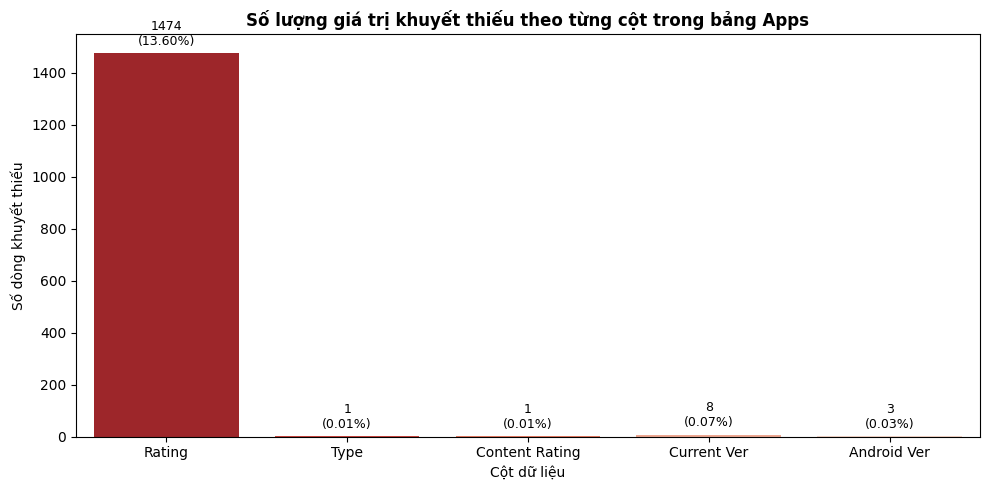

In [1]:
# Thống kê số lượng khuyết thiếu
missing_apps = df_apps.isnull().sum()
missing_apps_pct = (df_apps.isnull().sum() / len(df_apps)) * 100

print("--- Khuyết thiếu ở bảng Apps ---")
print(missing_apps)

# Trực quan hóa giá trị khuyết thiếu trong bảng Apps
plt.figure(figsize=(10, 5))
cols_with_missing = missing_apps[missing_apps > 0]
if not cols_with_missing.empty:
    sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values, palette='Reds_r')
    plt.title("Số lượng giá trị khuyết thiếu theo từng cột trong bảng Apps", fontsize=12, fontweight='bold')
    plt.ylabel("Số dòng khuyết thiếu")
    plt.xlabel("Cột dữ liệu")
    for i, v in enumerate(cols_with_missing.values):
        plt.text(i, v + 20, f"{v}\n({missing_apps_pct[cols_with_missing.index[i]]:.2f}%)", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\n--- Khuyết thiếu ở bảng Reviews ---")
missing_reviews = df_reviews.isnull().sum()
print(missing_reviews)


**Nhận xét/Giải thích:**
- Trong bảng Apps, cột `Rating` bị thiếu nhiều nhất với **1,474 dòng** (chiếm 13.59% tổng dữ liệu). Biểu đồ cột màu đỏ thể hiện trực quan mức độ khuyết thiếu tập trung chủ yếu vào cột này. Các cột khác thiếu rất ít (dưới 10 dòng).
- Trong bảng Reviews, các cột `Translated_Review`, `Sentiment`, `Sentiment_Polarity`, `Sentiment_Subjectivity` đều bị thiếu khoảng **26,863 dòng** (chiếm tới 41.78%). Tỷ lệ này cực kỳ lớn, cho thấy số lượng lớn bình luận bị để trống.


## 1.2. Khảo sát dữ liệu trùng lặp (Duplicates)


In [1]:
dup_apps_count = df_apps['App'].duplicated().sum()
print(f"Số lượng tên ứng dụng bị trùng lặp: {dup_apps_count} / {len(df_apps)}")
print("Ví dụ về ứng dụng trùng lặp:")
print(df_apps[df_apps['App'].duplicated(keep=False)].sort_values(by='App').head(4)[['App', 'Category', 'Reviews', 'Installs']])


Số lượng tên ứng dụng bị trùng lặp: 1181 / 10841
Ví dụ về ứng dụng trùng lặp:
                             App            Category Reviews    Installs
1393       10 Best Foods for You  HEALTH_AND_FITNESS    2490    500,000+
1407       10 Best Foods for You  HEALTH_AND_FITNESS    2490    500,000+
2322  1800 Contacts - Lens Store             MEDICAL   23160  1,000,000+
2543  1800 Contacts - Lens Store             MEDICAL   23160  1,000,000+


**Nhận xét/Giải thích:**
- Bảng Apps chứa **1,181 tên ứng dụng trùng lặp**. Một số ứng dụng xuất hiện nhiều lần (ví dụ: *ROBLOX*, *Quick PDF Scanner*) do được crawl tại nhiều thời điểm khác nhau. Số lượng reviews và lượt installs của các bản ghi trùng lặp này có sự khác biệt nhỏ. Cần thiết lập quy tắc giữ lại bản ghi mới nhất (thường là bản ghi có số lượng `Reviews` lớn nhất).


# 2. Khảo sát chi tiết các cột dữ liệu và phát hiện bất thường


## 2.1. Kiểm tra định dạng của các cột (Installs, Price, Size, Reviews)


--- Mẫu giá trị cột Installs ---
<ArrowStringArray>
[     '10,000+',     '500,000+',   '5,000,000+',  '50,000,000+',
     '100,000+',      '50,000+',   '1,000,000+',  '10,000,000+',
       '5,000+', '100,000,000+']
Length: 10, dtype: str

--- Mẫu giá trị cột Price ---
<ArrowStringArray>
[    '0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
 '$3.49', '$1.99']
Length: 10, dtype: str

--- Mẫu giá trị cột Size ---
<ArrowStringArray>
['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M', '28M']
Length: 10, dtype: str


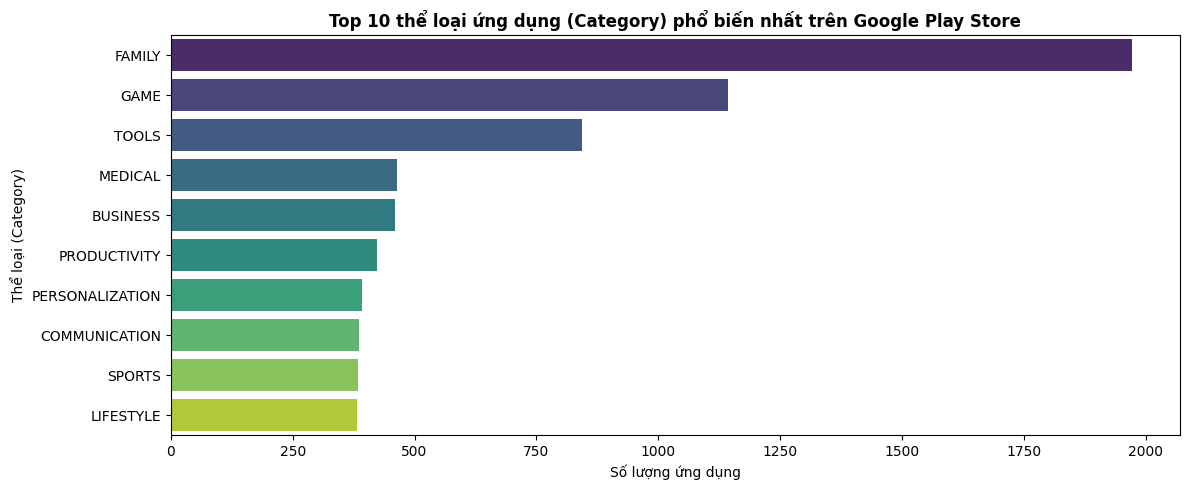

In [1]:
print("--- Mẫu giá trị cột Installs ---")
print(df_apps['Installs'].unique()[:10])

print("\n--- Mẫu giá trị cột Price ---")
print(df_apps['Price'].unique()[:10])

print("\n--- Mẫu giá trị cột Size ---")
print(df_apps['Size'].unique()[:10])

# Vẽ phân phối các thể loại ứng dụng (Top 10 Category phổ biến nhất)
plt.figure(figsize=(12, 5))
top_cats = df_apps['Category'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, palette='viridis')
plt.title("Top 10 thể loại ứng dụng (Category) phổ biến nhất trên Google Play Store", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng ứng dụng")
plt.ylabel("Thể loại (Category)")
plt.tight_layout()
plt.show()


**Nhận xét/Giải thích:**
- Cột `Installs` đang có định dạng chuỗi chứa dấu `+` và dấu phẩy `,` (ví dụ: `10,000+`). Cột `Price` chứa ký tự đơn vị tiền tệ `$` (ví dụ: `$4.99`). Cột `Size` chứa các ký tự đơn vị `M` (Megabytes), `k` (Kilobytes) và chuỗi `"Varies with device"`.
- Biểu đồ thanh hiển thị Top 10 Category phổ biến nhất trên Play Store, cho thấy thể loại `FAMILY`, `GAME`, `TOOLS` chiếm số lượng lớn nhất trong tập mẫu.


## 2.2. Phát hiện dòng bị lệch cột (Shifted Row)


In [1]:
shifted_rows = df_apps[df_apps['Installs'] == 'Free']
print("Dòng bị lệch cột trong bảng Apps:")
print(shifted_rows)


Dòng bị lệch cột trong bảng Apps:
                                           App Category  ...  Current Ver Android Ver
10472  Life Made WI-Fi Touchscreen Photo Frame      1.9  ...   4.0 and up         NaN

[1 rows x 13 columns]


**Nhận xét/Giải thích:**
- Phát hiện dòng chỉ mục **10472** (App: *Life Made WI-Fi Touchscreen Photo Frame*) bị lệch cột nghiêm trọng: cột `Category` bị trống khiến tất cả các thuộc tính phía sau bị đẩy lệch sang trái (cột `Rating` nhận giá trị `19.0` - là giá trị vô lý, cột `Installs` nhận giá trị `'Free'`, cột `Price` nhận giá trị `'Everyone'`). Dòng lệch này cần được loại bỏ khỏi tập dữ liệu.
